# Recap: Let's meet Olist

## 🎯 Objectives

👀 Peak ahead to the next units

🏪 Understand the data structure of a typical e-commerce platform

💪 Recap the most important SQL statements with real data

## Context

🔥 In the next units, you'll work as a data scientist on a real case study!

💸 Objective: help the business owners in their **Decision-Making Process**

📈 In-depth analysis of historical business data

🕵🏻 Discover your first (linear) **Statistical Models**: the Linear Regression and the Logistic Regression
- ❗️ No fancy predictions of the future
- 👀 Find correlations between variables, i.e. make your data speak
- 🎲 Use **Statistical Inference** to prove the robustness of your findings

🗣 **Present** your analysis

## Who or what is Olist?

Olist is a Brazilian e-commerce company

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/olist.png' width='400'>

🗓  Founded in 2015 

🇧🇷 Operates in Brazil

💻 100% digital company <br> *(Pure Digital Player, i.e. business operations fully managed online)*

💸  Total Funding Amount $\approx$ 136M USD (accumulated from 2015 to 2021) <br> *Source: [CrunchBase/Olist/CompanyFinancials](https://www.crunchbase.com/organization/olist/company_financials)*

### What does Olist do?

🛒 Online e-commerce service for sellers

🤝 Connects (small) merchants to the most important marketplaces in Brazil (Amazon, Bahia, Walmart, ...)

✅ Offers *Logistic and Inventory Management Services* to sellers

❗️ Does *NOT* sell anything directly to consumers

### The <strong>Seller</strong> workflow ⚙️
    
The seller:

1. joins Olist
2. uploads their product catalogues
    - (Olist) displays these catalogues on existing marketplaces (Amazon, Bahia, Walmart, ...)
3. gets notified whenever a product is sold
4. hands over the ordered items to third-party logistic carriers 

_Note: Multiple sellers can be involved in one customer's order!_

### The <strong>Customer</strong> workflow ⚙️

The customer:

1. browses products on marketplaces (Amazon, Bahia, Walmart, ...)
2. purchases products listed via `Olist.store`
3. gets an expected date for delivery
    - *ETA = Estimated Time of Arrival (of the orders)*
4. receives the order(s)
5. leaves a review

_Note: Between 2016 and mid-2018, a review could be left as soon as the order was sent, meaning that a customer could potentially leave a review for a product they hadn't received yet!_

### Dataset 

*About the data:* 🔢
    
- Released on Kaggle in November 2018
    - [kaggle.com/olistbr/brazilian-ecommerce](https://www.kaggle.com/olistbr/brazilian-ecommerce)
- **`Information about ~100k orders made between 2016 and 2018`**
- **`8 csv files, ~120mb`**
- Real data! 
    - Marketplaces' and merchants' identifiable information have been anonymized
- The full documentation is available in the `/data` directory of the 1<sup>st</sup> challenge of the unit

Data Model: 

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/olist_data_schema.png' width='800'> 

## Let's retrieve some data!

We want to build a data model to analyse our data using statistical models.

Later, we would be able to use the same model for Machine Learning tasks. Data preparation is one of the most important aspects in Data Science!

We'll build the following models:
- Orders
- Sellers
- Products

In the next unit we'll build Python classes for these models, but let's warm up the SQL way!

#### Load the data

In the next unit we'll use the original csv files, but we put them in a SQLite database for today!

In [ ]:
!mkdir -p ~/.lewagon/olist/data
!curl https://wagon-public-datasets.s3.amazonaws.com/sql_databases/olist_raw.sqlite > ~/.lewagon/olist/data/olist_raw.sqlite

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
 77  129M   77  100M    0     0  1164k      0  0:01:54  0:01:28  0:00:26 1177k

You know the drill: make a connection

In [82]:
from pathlib import Path
from sqlite3 import connect
import pandas as pd

db_path = Path('~/.lewagon/olist/data/olist_raw.sqlite').expanduser()

conn = connect(db_path)

Let's check the tables inside our SQLite database (hint: check the table `sqlite_schema` in your database):

A little gift: the complete ERD for you. It's a nice gift: you'll want to come back to it regularly...

<img src="https://wagon-public-datasets.s3.amazonaws.com/04-Decision-Science/01-Project-Setup/olist_schema_v2.png" width=1000>

### Enrich our orders data

#### 1. Let's only keep delivered orders

In [90]:
select_all_delivered_orders = """
  select * from orders where order_status = 'delivered'
"""
orders_df = pd.read_sql(select_all_delivered_orders, conn)
orders_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
96473,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
96474,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
96475,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
96476,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


Let's get the number of items for each order and add it to our model. Check the ERD!

Start by getting the number of items for each order. (We like to build it up slowly.)

Will there be orders with more than item? What do you think?

Check their distribution.

array([[<Axes: title={'center': 'items_count'}>]], dtype=object)

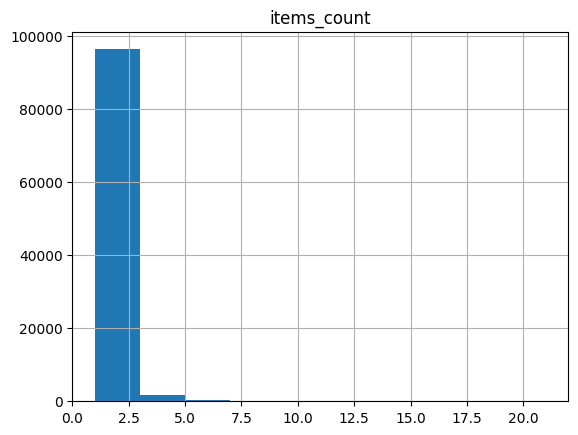

In [89]:
select_order_id_and_number_of_items = """
  select order_id, count() items_count from order_items group by order_id;
"""

order_items_df = pd.read_sql(select_order_id_and_number_of_items, conn)
order_items_df.hist()

In [92]:
order_items_df

,order_id,items_count
0,00010242fe8c5a6d1ba2dd792cb16214,1
1,00018f77f2f0320c557190d7a144bdd3,1
2,000229ec398224ef6ca0657da4fc703e,1
3,00024acbcdf0a6daa1e931b038114c75,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1
...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,1
98662,fffcd46ef2263f404302a634eb57f7eb,1
98663,fffce4705a9662cd70adb13d4a31832d,1
98664,fffe18544ffabc95dfada21779c9644f,1


Now, let's combine our orders information and the number of items. With SQL only!

In [91]:
orders_and_item_counts = """
with
  tmp as (
    select
      order_id,
      count() as items_count
    from
      order_items
    group by
      order_id
  )
select
  orders.*,
  tmp.items_count
from
  orders
  join tmp on tmp.order_id = orders.order_id
where
  order_status = 'delivered';
"""

pd.read_sql(orders_and_item_counts, conn)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,items_count
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1
...,...,...,...,...,...,...,...,...,...
96473,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,1
96474,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,1
96475,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,1
96476,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,2


How would you do the same with Pandas? Starting from `orders_df` and `order_items_df`. Did you get the same number?

In [95]:
orders_df.merge(order_items_df, on="order_id")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,items_count
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1
...,...,...,...,...,...,...,...,...,...
96473,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,1
96474,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,1
96475,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,1
96476,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,2


Let's add the total sales for each order. Don't reinvent the wheel: you have almost everything you need!

In [ ]:
orders_with_item_count_and_total_price = """
-- Select orders with the items count attached
with
  tmp as (
    select
      order_id,
      count() as items_count,
      sum(price) as total_price
    from
      order_items
    group by
      order_id
  )
select
  orders.*,
  tmp.items_count,
  tmp.total_price
from
  orders
  join tmp on tmp.order_id = orders.order_id
where
  order_status = 'delivered';
"""

Let's plot sales over time. Which timestamp will you use? Check its data types first.

In [ ]:
# YOUR CODE HERE

Let's solve that. We could do it in SQL, but let's use Pandas this time (remember this for tomorrow).

In [ ]:
# YOUR CODE HERE

Time to plot:

In [ ]:
# YOUR CODE HERE

As a data scientist, one of the most important things when visualizing data is choosing the right data and chart.

Did you like this one? How can you improve it?

In [ ]:
# YOUR CODE HERE

What explains the evolution over time best? Are we selling more items? Or are we selling more expensive goods? How can you know?

In the previous plot, replace the `sum` with `mean` and `count`. What do you learn?

### Closing it up

Before we wrap this up, let's not forget to close the connection:

In [ ]:
conn.close()

## 🏁 Conclusion

We learned about Olist and its data: make sure to come back to the ERD regulary in the coming units.

We learned that we can do similar things with 🐼🐼🐼 and SQL 🗃️.

We can make more interesting data models by combining information from different tables. 
- With `JOIN` in SQL
- With `pd.merge()` in Pandas (or `pd.join()` if you want to join on the index)
- In both cases we'll have to decide which join we apply: inner, left (or right or outer, but that's pretty rare)

Now we have everything in our data toolkit, we're ready to dive into decision science 🚀